In [1]:
!pip install sentence-transformers


In [2]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
sentences = [
    #  Cricket (4 sentences)
    "India beat New Zealand to win the 2026 T20 World Cup.",
    "Jasprit Bumrah was the leading wicket taker for India.",
    "The batsman hit a massive six over long-on to win the match.",
    "A good spin bowler can turn the ball sharply on a dry pitch.",

    # Cooking (3 sentences)
    "Read the entire recipe before you start prepping any ingredients.",
    "Always taste your food and adjust seasoning as you cook.",
    "Chopping vegetables into uniform sizes ensures they cook evenly.",

    #Cybersecurity (3 sentences)
    "Always use strong, unique passwords for every online account.",
    "Keep your software updated to patch known security vulnerabilities.",
    "Do not click on suspicious links or download attachments from unknown senders.",
]

print(f'Total sentences: {len(sentences)}')
for i, s in enumerate(sentences):
    print(f'  S{i+1}: {s}')


Total sentences: 10
  S1: India beat New Zealand to win the 2026 T20 World Cup.
  S2: Jasprit Bumrah was the leading wicket taker for India.
  S3: The batsman hit a massive six over long-on to win the match.
  S4: A good spin bowler can turn the ball sharply on a dry pitch.
  S5: Read the entire recipe before you start prepping any ingredients.
  S6: Always taste your food and adjust seasoning as you cook.
  S7: Chopping vegetables into uniform sizes ensures they cook evenly.
  S8: Always use strong, unique passwords for every online account.
  S9: Keep your software updated to patch known security vulnerabilities.
  S10: Do not click on suspicious links or download attachments from unknown senders.


In [4]:
# Load the pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convert every sentence into an embedding (a list of 384 numbers)
embeddings = model.encode(sentences, convert_to_tensor=True)

print(f'Shape of embeddings: {embeddings.shape}')
print('  → 10 sentences, each turned into a vector of 384 numbers')

Model loaded successfully.


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of embeddings: torch.Size([10, 384])
  → 10 sentences, each turned into a vector of 384 numbers


In [5]:
# Compute cosine similarity for every pair of sentences
cosine_scores = util.cos_sim(embeddings, embeddings)

# Convert to a regular numpy array
sim_matrix = cosine_scores.numpy()

print('Similarity matrix shape:', sim_matrix.shape)
print('Sample — similarity between S1 (Cricket) and S2 (Cricket):',
      round(float(sim_matrix[0][1]), 3))
print('Sample — similarity between S1 (Cricket) and S5 (Cooking):',
      round(float(sim_matrix[0][4]), 3))

Similarity matrix shape: (10, 10)
Sample — similarity between S1 (Cricket) and S2 (Cricket): 0.333
Sample — similarity between S1 (Cricket) and S5 (Cooking): -0.078


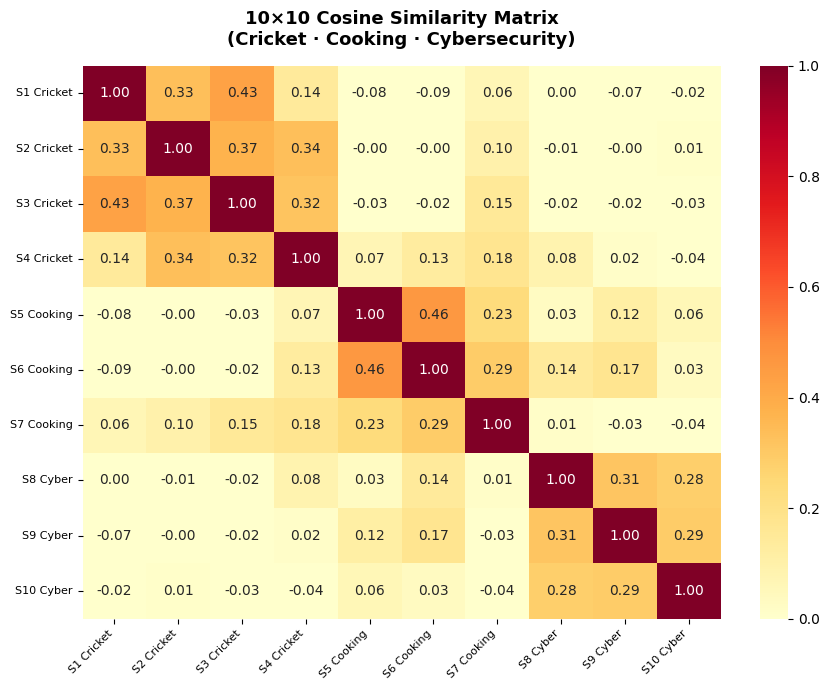

In [6]:
labels = [
    "S1 Cricket", "S2 Cricket", "S3 Cricket", "S4 Cricket",
    "S5 Cooking", "S6 Cooking", "S7 Cooking",
    "S8 Cyber",   "S9 Cyber",   "S10 Cyber"
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    ax=ax
)
ax.set_title('10×10 Cosine Similarity Matrix\n(Cricket · Cooking · Cybersecurity)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
query = 'The bowler took three wickets in one over.'

# Embed the query
query_embedding = model.encode(query, convert_to_tensor=True)

# Comparing the query against all 10 sentences
query_scores = util.cos_sim(query_embedding, embeddings)[0]

# Sorting by score (highest first)
ranked = sorted(enumerate(query_scores), key=lambda x: x[1], reverse=True)

print(f'Query: "{query}"')
print('─' * 60)
print('Top 2 most similar sentences:')
print()
for rank, (idx, score) in enumerate(ranked[:2], start=1):
    print(f'  Rank {rank}: "{sentences[idx]}"')
    print(f'           Similarity score: {float(score):.3f}')
    print()



Query: "The bowler took three wickets in one over."
────────────────────────────────────────────────────────────
Top 2 most similar sentences:

  Rank 1: "The batsman hit a massive six over long-on to win the match."
           Similarity score: 0.606

  Rank 2: "Jasprit Bumrah was the leading wicket taker for India."
           Similarity score: 0.505

